# Import modules

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

sc.settings.verbosity = 1  # verbosity: errors (0), warnings (1), info (2), hints (3)

In [2]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:356: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [3]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'
os.makedirs(figdir,exist_ok=True)
# table_dir = '/nfs/team205/heart/fetal_ms_figures/tables/Aug2024'

# Variables

In [4]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
path_adata_tacco = f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_rm-unclassified_raw.h5ad'
path_adata_original = f'{data_object_dir}/all_b2c_cells_filtered_celltype-sel_rm-unclassified_raw.h5ad'
celltype_col = 'fine_grain_2Feb2026'

# Read in qeury adata

In [5]:
# read in tacco-treated adata
adata_tacco = sc.read_h5ad(path_adata_tacco)
adata_tacco

AnnData object with n_obs × n_vars = 189948 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'fine_grain_2Feb2026', 'mid_grain_2Feb2026'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_tacco_ref-hd-scn_colors', 'donor

In [6]:
# read in original adata
adata_orig = sc.read_h5ad(path_adata_original)
adata_orig

AnnData object with n_obs × n_vars = 189948 × 18085
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'fine_grain_2Feb2026'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_pre_colors', 'donor_colors', 'library_colors', 'neighbors', 'spatial', 'umap'
    obsm: 'spatial', 'spati

In [7]:
print(adata_tacco.X.data[:5])
print(adata_orig.X.data[:5])

[1. 2. 2. 1. 1.]
[1. 2. 2. 1. 1.]


In [8]:
# update cell type name for plotting
df = pd.read_csv('/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/finegrain_name_mapping.csv')
celltype_mapping = df.set_index('Full_name')['Short_name_finalised'].to_dict()
adata_tacco.obs.replace({celltype_col:celltype_mapping},inplace=True)
adata_orig.obs.replace({celltype_col:celltype_mapping},inplace=True)

/tmp/ipykernel_411479/1449222922.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_tacco.obs.replace({celltype_col:celltype_mapping},inplace=True)
/tmp/ipykernel_411479/1449222922.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_orig.obs.replace({celltype_col:celltype_mapping},inplace=True)


In [9]:
set(adata_tacco.obs[celltype_col])

{'AVNPC',
 'ArtEC',
 'CorCapEC',
 'CorMural',
 'DASMC',
 'EPDC',
 'Endocard',
 'FB',
 'FBCOL2A1',
 'FBPITX2',
 'GVSMC',
 'ILC',
 'LymphEC',
 'MPLYVE1',
 'MacCX3',
 'MesEpiC',
 'Mono',
 'NK',
 'ParaN',
 'SANPCHd',
 'SANPCTl',
 'SHPC',
 'SchwC',
 'SympN',
 'VCSDist',
 'VCSProx',
 'ValveEC',
 'ValveIC',
 'VenEC',
 'aCML',
 'aCMNeur',
 'aCMR',
 'aCMTrans',
 'vCMC',
 'vCMT'}

In [10]:
# keep cells which are in the reference
cells_keep = [
    'AVNPC',
     'ArtEC',
     'CorCapEC',
     'CorMural',
     'DASMC',
     'EPDC',
     'Endocard',
     'FB',
     'FBCOL2A1',
     'FBPITX2',
     'GVSMC',
     'ILC',
     'LymphEC',
     'MPLYVE1',
     'MacCX3',
     'MesEpiC',
     'Mono',
     'NK',
     'ParaN',
     'SANPCHd',
     'SANPCTl',
     'SHPC',
     'SchwC',
     'SympN',
     'VCSDist',
     'VCSProx',
     'ValveEC',
     'ValveIC',
     'VenEC',
     'aCML',
     'aCMR',
     'vCMC',
     'vCMT'
]
adata_tacco = adata_tacco[adata_tacco.obs[celltype_col].isin(cells_keep)]
adata_orig = adata_orig[adata_orig.obs[celltype_col].isin(cells_keep)]

# Read in reference adata

In [11]:
adata_ref = sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/RNA/Feb28ObjectRaw_finegrain_updated.h5ad')
adata_ref

AnnData object with n_obs × n_vars = 297473 × 36601
    obs: 'latent_RT_efficiency', 'latent_cell_probability', 'latent_scale', 'sangerID', 'combinedID', 'donor', 'region', 'age', 'facility', 'cell_or_nuclei', 'modality', 'kit_10x', 'scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'HB_score', 'donor_by_library-prep', 'multiplexed', 'SOC | status', 'SOC | log_prob_singleton', 'SOC | log_prob_doublet', 'batch_key', '_scvi_batch', 'FACSgate', 'fine_grain', 'mid_grain', 'coarse_grain', 'sex', 'week', 'trimester', 'heart_or_greatvessels', 'cycling', 'S_score', 'G2M_score', 'phase', '_scvi_labels', 'stress_score', 'hb1_score'
    var: 'gene_name_scRNA-0', 'gene_id'
    uns: 'FACSgate_colors', '_scvi_manager_uuid', '_scvi_uuid', 'age_colors', 'cell_or_nucl

In [12]:
# update cell type name
df = pd.read_csv('/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/finegrain_name_mapping.csv')
celltype_mapping = df.set_index('Full_name')['Short_name_finalised'].to_dict()
adata_ref.obs.replace({'fine_grain':celltype_mapping},inplace=True)
set(adata_ref.obs['fine_grain'])

/tmp/ipykernel_411479/2922240176.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_ref.obs.replace({'fine_grain':celltype_mapping},inplace=True)


{'AVNPC',
 'B',
 'BMS4',
 'ChromC',
 'CorAdvFB',
 'CorArtEC',
 'CorCapEC',
 'CorPeri',
 'CorSMC',
 'CorVenEC',
 'DASMC',
 'DCMat',
 'DCT1',
 'EPDC',
 'EndoCush',
 'Endocard',
 'GVAdvFB',
 'GVArtEC',
 'GVSMC',
 'GVVenEC',
 'ILC',
 'LNFRC',
 'LymphEC',
 'MPATF3',
 'MPLYVE1',
 'MPTIMD4',
 'MacCX3',
 'MastC',
 'MegaK',
 'MesEpiC',
 'MoDC',
 'Mono',
 'MonoMPO',
 'MyoFB',
 'MyoFb',
 'NK',
 'NeuroPre',
 'ParaN',
 'PericFib',
 'PericInt',
 'PericPar',
 'ProB',
 'SANPC',
 'SchwC',
 'SchwP',
 'SubEpiFb',
 'SympN',
 'TCD4',
 'TCD8',
 'Treg',
 'VCSDist',
 'VCSProx',
 'ValveEC',
 'ValveIC',
 'aCMCyc',
 'aCML',
 'aCMR',
 'pDC',
 'vCMCL',
 'vCMCR',
 'vCMCyc',
 'vCMTL',
 'vCMTR'}

# Select shared genes and log-normalise

In [13]:
shared_genes = list(set(adata_tacco.var_names).intersection(adata_ref.var_names))
print(len(shared_genes))
adata_tacco = adata_tacco[:,shared_genes]
print(adata_tacco.shape)
adata_orig = adata_orig[:,shared_genes]
print(adata_orig.shape)
adata_ref = adata_ref[:,shared_genes]
print(adata_ref.shape)

18077
(188221, 18077)
(188221, 18077)
(297473, 18077)


In [14]:
# log normalise
print('log-normalising spatial data (tacco-treated)...')
print(adata_tacco.X.data[:5])
sc.pp.normalize_total(adata_tacco,target_sum=1e4)
sc.pp.log1p(adata_tacco)
print(adata_tacco.X.data[:5])

print('log-normalising spatial data (original)...')
print(adata_orig.X.data[:5])
sc.pp.normalize_total(adata_orig,target_sum=1e4)
sc.pp.log1p(adata_orig)
print(adata_orig.X.data[:5])

print('log-normalising single-cell/nuc data...')
print(adata_ref.X.data[:5])
sc.pp.normalize_total(adata_ref,target_sum=1e4)
sc.pp.log1p(adata_ref)
print(adata_ref.X.data[:5])

log-normalising spatial data (tacco-treated)...
[1. 2. 2. 1. 1.]


/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


[1.22084684 1.75442353 1.75442353 1.22084684 1.22084684]
log-normalising spatial data (original)...
[1. 2. 2. 1. 1.]
[1.1784127 1.7044618 1.7044618 1.1784127 1.1784127]
log-normalising single-cell/nuc data...
[ 5.  5.  8.  4. 13.]
[0.5546135  0.5546135  0.7820865  0.46562803 1.0740793 ]


# Harmonise cell type names

In [15]:
# Double-checking tacco and original adata has same cell type labels
print(set(adata_tacco.obs[celltype_col]) - set(adata_orig.obs[celltype_col]))
print(set(adata_orig.obs[celltype_col]) - set(adata_tacco.obs[celltype_col]))

set()
set()


In [16]:
set(adata_ref.obs['fine_grain']) - set(adata_tacco.obs[celltype_col])

{'B',
 'BMS4',
 'ChromC',
 'CorAdvFB',
 'CorArtEC',
 'CorPeri',
 'CorSMC',
 'CorVenEC',
 'DCMat',
 'DCT1',
 'EndoCush',
 'GVAdvFB',
 'GVArtEC',
 'GVVenEC',
 'LNFRC',
 'MPATF3',
 'MPTIMD4',
 'MastC',
 'MegaK',
 'MoDC',
 'MonoMPO',
 'MyoFB',
 'MyoFb',
 'NeuroPre',
 'PericFib',
 'PericInt',
 'PericPar',
 'ProB',
 'SANPC',
 'SchwP',
 'SubEpiFb',
 'TCD4',
 'TCD8',
 'Treg',
 'aCMCyc',
 'pDC',
 'vCMCL',
 'vCMCR',
 'vCMCyc',
 'vCMTL',
 'vCMTR'}

In [17]:
set(adata_tacco.obs[celltype_col]) - set(adata_ref.obs['fine_grain'])

{'ArtEC',
 'CorMural',
 'FB',
 'FBCOL2A1',
 'FBPITX2',
 'SANPCHd',
 'SANPCTl',
 'SHPC',
 'VenEC',
 'vCMC',
 'vCMT'}

In [18]:
celltype_mapping_2 = {
    # unique in single-cell/nuc data
    'BMS4':'B',
    'CorAdvFB':'FB',
    'GVAdvFB':'FB',
    'MyoFB':'FB',
    'MyoFb':'FB',
    'MonoMPO':'Mono',
     'ProB':'B',
    'SubEpiFb':'FB',
    'CorArtEC':'ArtEC',
    'GVArtEC':'ArtEC',
    'CorVenEC':'VenEC',
    'GVVenEC':'VenEC',
    'EndoCush':'Endocard',
    'CorPeri':'CorMural',
    'CorSMC':'CorMural',
    'vCMCL':'vCMC',
    'vCMCR':'vCMC',
    'vCMTL':'vCMT',
    'vCMTR':'vCMT',
    # unique in VisiumHD data
    'FBCOL2A1':'FB',
    'FBPITX2':'FB',
    'SANPCHd':'SANPC',
     'SHPC':'SANPC',
     'SANPCTl':'SANPC',
}
adata_tacco.obs[celltype_col] = [celltype_mapping_2[x] if x in celltype_mapping_2.keys() else x for x in adata_tacco.obs[celltype_col]]
adata_orig.obs[celltype_col] = [celltype_mapping_2[x] if x in celltype_mapping_2.keys() else x for x in adata_orig.obs[celltype_col]]
adata_ref.obs['fine_grain'] = [celltype_mapping_2[x] if x in celltype_mapping_2.keys() else x for x in adata_ref.obs['fine_grain']]

In [19]:
print(set(adata_ref.obs['fine_grain']) - set(adata_tacco.obs[celltype_col]))
print(set(adata_tacco.obs[celltype_col]) - set(adata_ref.obs['fine_grain']))

{'MPATF3', 'DCT1', 'Treg', 'MoDC', 'MPTIMD4', 'TCD8', 'ChromC', 'SchwP', 'PericPar', 'TCD4', 'pDC', 'DCMat', 'MastC', 'vCMCyc', 'LNFRC', 'PericInt', 'PericFib', 'NeuroPre', 'B', 'MegaK', 'aCMCyc'}
set()


--> reference scnRNAseq adata has extra cell types compared to spatial data

In [20]:
# select cell types in the spatial dataset
adata_ref = adata_ref[adata_ref.obs['fine_grain'].isin(list(set(adata_tacco.obs[celltype_col])))]

# Select features from the scnRNAseq data

In [21]:
# Mid-grained cell type-specific DEGs
mid_degs = utils.rank_genes_groups_with_mean(adata_ref,groupby='mid_grain',log2fc_min=0)

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(group_key)


In [22]:
# Fine-grained cell type-specific DEGs
count = 0
for cell in set(adata_ref.obs['mid_grain']):
    print(cell)
    adata_sub = adata_ref[adata_ref.obs['mid_grain']==cell]
    if len(set(adata_sub.obs['fine_grain']))>1:
        count+=1
        print('calculating DEGs')
        res = utils.rank_genes_groups_with_mean(adata_sub,groupby='fine_grain',log2fc_min=0)
        res['midgrain_celltype'] = cell
        if count==1:
            fine_degs = res.copy()
        else:
            fine_degs = pd.concat([fine_degs,res])
        
fine_degs

BloodVesselEndothelialCells
calculating DEGs


/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(group_key)


AtrialCardiomyocytes
calculating DEGs


/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(group_key)


VentricularCardiomyocytes
calculating DEGs


...

/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(group_key)


MyeloidCells
calculating DEGs


/home/kk837/.conda/envs/generic_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby(group_key)


LymphaticEndothelialCells


,group,names,scores,logfoldchanges,pvals,pvals_adj,group_mean,midgrain_celltype
0,ArtEC,ELN,170.698730,7.385557,0.000000,0.000000,4.648954,BloodVesselEndothelialCells
1,ArtEC,SULF1,115.601639,6.276546,0.000000,0.000000,2.830216,BloodVesselEndothelialCells
2,ArtEC,FBLN5,94.856438,5.484433,0.000000,0.000000,2.056849,BloodVesselEndothelialCells
3,ArtEC,DKK2,93.669983,6.053082,0.000000,0.000000,2.182732,BloodVesselEndothelialCells
4,ArtEC,COL1A2,91.848770,4.106546,0.000000,0.000000,2.931160,BloodVesselEndothelialCells
...,...,...,...,...,...,...,...,...
12005,Mono,GSE1,2.214070,0.292685,0.026969,0.048972,0.198678,MyeloidCells
12006,Mono,ARL8A,2.213437,0.206707,0.027012,0.049040,0.327871,MyeloidCells
12007,Mono,EMD,2.207955,0.203647,0.027391,0.049658,0.309475,MyeloidCells
12008,Mono,CCDC51,2.207144,0.528837,0.027449,0.049749,0.038888,MyeloidCells


In [23]:
# get genes
group_mean_thresh = 1
logfoldchanges_thresh = 1

mask1 = mid_degs['group_mean']>group_mean_thresh
mask2 = mid_degs['logfoldchanges']>logfoldchanges_thresh
mid_genes = list(set(mid_degs[mask1&mask2]['names']))
print(len(mid_genes))

mask1 = fine_degs['group_mean']>group_mean_thresh
mask2 = fine_degs['logfoldchanges']>logfoldchanges_thresh
fine_genes = list(set(fine_degs[mask1&mask2]['names']))
print(len(fine_genes))

degs_all = list(set(mid_genes+fine_genes))
print(len(degs_all))

1595
1452
2076


In [24]:
adata_tacco_sel = adata_tacco[:,degs_all]
adata_orig_sel = adata_orig[:,degs_all]
adata_ref_sel = adata_ref[:,degs_all]

# Calculare correlation

In [25]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

def adata_pearson_corr_with_p_vectorized(adata_que, adata_ref,
                                         celltype_col_que, celltype_col_ref, 
                                         aggrecation_func = "mean",
                                         p_adjust='fdr_bh'
                                        ):
    # aggregate count of the query adata
    adata_que_agg = sc.get.aggregate(adata_que, by=celltype_col_que, func=[aggrecation_func])
    adata_que_agg.X = adata_que_agg.layers[aggrecation_func]
    query_df = adata_que_agg.to_df().T.copy()
    print(f'query df, shape: {query_df.shape}')
    
    # aggregate count of the reference adata
    adata_ref_agg = sc.get.aggregate(adata_ref, by=celltype_col_ref, func=[aggrecation_func])
    adata_ref_agg.X = adata_ref_agg.layers[aggrecation_func]
    ref_df = adata_ref_agg.to_df().T.copy()
    print(f'ref_df, shape: {ref_df.shape}')
    
    # correlation
    # returning dataframe: index=query, columns=reference cell types
    corr, pval = utils.df_pearson_corr_with_p_vectorized(query_df, ref_df, p_adjust=p_adjust)
    return corr, pval

/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:356: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


### "scnRNAseq reference" & "tacco-treated Visium HD" adata

In [26]:
%%time
# returning dataframe: index=query, columns=reference cell types
corr_tacco, pval_tacco = adata_pearson_corr_with_p_vectorized(adata_tacco_sel, 
                                                  adata_ref_sel,
                                                  celltype_col_que=celltype_col, 
                                                  celltype_col_ref='fine_grain', 
                                                  aggrecation_func = "mean",
                                                  p_adjust='fdr_bh')

query df, shape: (2076, 29)
ref_df, shape: (2076, 29)
CPU times: user 3.93 s, sys: 333 ms, total: 4.26 s
Wall time: 4.3 s


### "scnRNAseq reference" & "original Visium HD" adata

In [27]:
%%time
# returning dataframe: index=query, columns=reference cell types
corr_orig, pval_orig = adata_pearson_corr_with_p_vectorized(adata_orig_sel, 
                                                  adata_ref_sel,
                                                  celltype_col_que=celltype_col, 
                                                  celltype_col_ref='fine_grain', 
                                                  aggrecation_func = "mean",
                                                  p_adjust='fdr_bh')

query df, shape: (2076, 29)
ref_df, shape: (2076, 29)
CPU times: user 4.14 s, sys: 385 ms, total: 4.53 s
Wall time: 4.44 s


# Compare the correlations between tacco and original

In [28]:
celltype_list = list(corr_tacco.index)

corr_tacco_list = []
corr_orig_list = []
for cell in celltype_list:
    corr_tacco_list.append(corr_tacco.loc[cell,cell])
    corr_orig_list.append(corr_orig.loc[cell,cell])
corr_compare_df = pd.DataFrame({'celltype':celltype_list,
                                'tacco':corr_tacco_list,
                                'original':corr_orig_list
                               })
corr_compare_df

,celltype,tacco,original
0,AVNPC,0.686884,0.679375
1,ArtEC,0.757831,0.754022
2,CorCapEC,0.742169,0.716898
3,CorMural,0.772897,0.740086
4,DASMC,0.691261,0.689141
5,EPDC,0.731470,0.683743
6,Endocard,0.732325,0.712339
7,FB,0.726057,0.712609
8,GVSMC,0.760234,0.761509
9,ILC,0.751584,0.457104


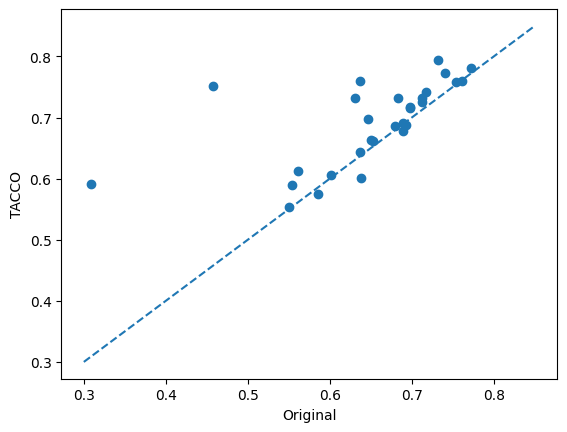

In [30]:
plt.scatter(x=corr_compare_df['original'],
            y=corr_compare_df['tacco'],
           )
# plt.xlim(0.3,0.9)
# plt.ylim(0.3,0.9)

# add diagonal reference line
lims = [0.3, 0.85]
plt.plot(lims, lims, linestyle='--')

plt.xlabel("Original")
plt.ylabel("TACCO")
plt.savefig(
    f"{figdir}/TACCO_original_corr_scatter_identical.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [31]:
import numpy as np
from scipy.stats import wilcoxon, binomtest

diff = corr_compare_df["tacco"] - corr_compare_df["original"]

# 1) Wilcoxon (paired, one-sided)
w, p_wil = wilcoxon(corr_compare_df["tacco"], corr_compare_df["original"],
                    alternative="greater")

# 2) Simple sign test (binomial) as a robustness check
k = int((diff > 0).sum())
n = len(diff)
p_sign = binomtest(k, n, p=0.5, alternative="greater").pvalue

print("n =", n)
print("Improved (diff>0) =", k, "/", n, f"({k/n:.1%})")
print("Mean diff =", diff.mean())
print("Median diff =", np.median(diff))
print("Wilcoxon p =", p_wil)
print("Sign test p =", p_sign)

n = 29
Improved (diff>0) = 24 / 29 (82.8%)
Mean diff = 0.040206841556754865
Median diff = 0.01348111121595208
Wilcoxon p = 6.956979632377625e-05
Sign test p = 0.0002730563282966614


# For each cell type, get mean of the correlation values with not-identical cell types (to assess the extent of contamination)

* for "other cell types", take fine-grained cell types which belongs to the different mid-grained category
* for example, for vCMC, take cell types outside ventricular CM

In [32]:
celltype_df = adata_ref.obs[['mid_grain','fine_grain']].copy()
celltype_df = celltype_df.drop_duplicates()
celltype_df.set_index('fine_grain',inplace=True)
print(celltype_df.shape)
celltype_df.head()

(29, 1)


,mid_grain
fine_grain,
CorCapEC,BloodVesselEndothelialCells
ILC,LymphoidCells
vCMC,VentricularCardiomyocytes
MPLYVE1,MyeloidCells
Mono,MyeloidCells


In [33]:
corr_tacco_list = []
corr_orig_list = []
for cell in celltype_df.index:
    mid_cell = celltype_df.loc[cell,'mid_grain']
    other_cell_list = list(celltype_df[celltype_df['mid_grain']!=mid_cell].index)
    corr_tacco_list.append(np.mean(corr_tacco.loc[cell,other_cell_list]))
    corr_orig_list.append(np.mean(corr_orig.loc[cell,other_cell_list]))
    
corr_others_compare_df = pd.DataFrame({'celltype':celltype_list,
                                'tacco':corr_tacco_list,
                                'original':corr_orig_list
                               })
corr_others_compare_df

,celltype,tacco,original
0,AVNPC,0.253449,0.284208
1,ArtEC,0.350050,0.361002
2,CorCapEC,0.305531,0.315476
3,CorMural,0.185115,0.231309
4,DASMC,0.240872,0.307910
5,EPDC,0.275359,0.290762
6,Endocard,0.297469,0.308411
7,FB,0.352653,0.383093
8,GVSMC,0.207211,0.251266
9,ILC,0.293861,0.311535


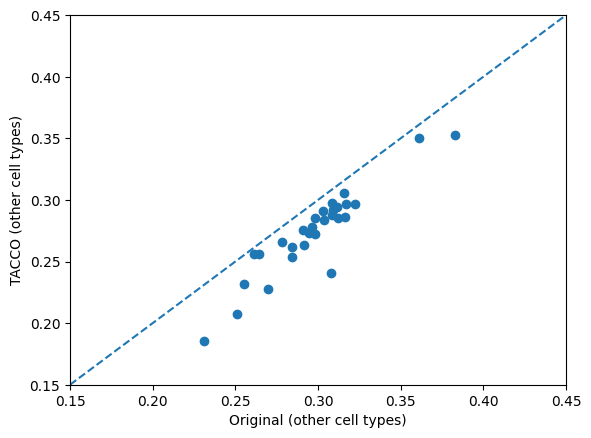

n = 29
Decreased (diff<0) = 29 / 29 (100.0%)
Mean diff = -0.023320914375426303
Median diff = -0.020764614408477045
Wilcoxon (TACCO<ORIG) p = 1.862645149230957e-09
Sign test p = 1.862645149230957e-09


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, binomtest

x = corr_others_compare_df['original'].to_numpy()
y = corr_others_compare_df['tacco'].to_numpy()
diff = y - x

# ---- plotting ----
plt.scatter(x=x, y=y)

# set limits (either fixed, or auto based on data)
lims = [0.15, 0.45]  # keep your fixed choice
plt.xlim(lims)
plt.ylim(lims)

# diagonal reference line y=x
plt.plot(lims, lims, linestyle='--')

plt.xlabel("Original (other cell types)")
plt.ylabel("TACCO (other cell types)")
plt.savefig(
    f"{figdir}/TACCO_original_corr_scatter_non-identical.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ---- stats ----
# 1) Wilcoxon (paired, one-sided): test TACCO < ORIGINAL
w, p_wil = wilcoxon(y, x, alternative="less")

# 2) Sign test (binomial): more negatives than expected under p=0.5
k = int((diff < 0).sum())
n = len(diff)
p_sign = binomtest(k, n, p=0.5, alternative="greater").pvalue

print("n =", n)
print("Decreased (diff<0) =", k, "/", n, f"({k/n:.1%})")
print("Mean diff =", diff.mean())
print("Median diff =", np.median(diff))
print("Wilcoxon (TACCO<ORIG) p =", p_wil)
print("Sign test p =", p_sign)

# Summary description

TACCO increased correlation with matched reference cell types (24/29 improved; mean Δr = 0.04; paired Wilcoxon p = 6.9×10⁻⁵) while simultaneously decreasing correlation with non-matching cell types in all cases (29/29 decreased; mean Δr = −0.023; paired Wilcoxon p = 1.9×10⁻⁹), consistent with improved cell-type specificity and reduced cross-lineage contamination.